<a href="https://colab.research.google.com/github/ivanovyeppez/talento-tech/blob/main/Experiencia/RedNeuronalRegresion_Keras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import keras
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Cargar el conjunto de datos
housing = fetch_california_housing()

# Crear conjuntos de datos de entrenamiento, validación y prueba
X_train_full, X_test, y_train_full, y_test = train_test_split(housing.data, housing.target)
X_train, X_valid, y_train, y_valid = train_test_split(X_train_full, y_train_full)

print('X_train:',X_train.shape)
print('X_test:',X_test.shape)
print('X_valid:',X_valid.shape)
print('y_train:',y_train.shape)
print('y_test:',y_test.shape)
print('y_valid:',y_valid.shape)

X_train: (11610, 8)
X_test: (5160, 8)
X_valid: (3870, 8)
y_train: (11610,)
y_test: (5160,)
y_valid: (3870,)


In [ ]:
# Escalar los datos
# Siempre se debe standarizar, normalizar los datos, tiene una escala comprimida y trabaja mejor.
# Se debe descomprimir la escala para volver a mostrar los datos
# Se debe dejar los datos
scaler = StandardScaler() #Variable que guarda e
X_train = scaler.fit_transform(X_train) # Solo se necesitan los campos X, van a la entrada de las neuronas, porque los Y, son los campos de resultados.
X_test = scaler.transform(X_test)
X_valid = scaler.transform(X_valid)

In [ ]:
# Crear el modelo de red neuronal:
# La red neuronal, depende de la calidad del DataSet,
# Si los datos estàn bien, la red puede subajustarce o sobreajustarce.
# Se puede trabajar para comenzar con una capa intermedia.
model = keras.models.Sequential([
    keras.layers.Dense(30, activation='relu',
                       input_shape=X_train.shape[1:]),
    keras.layers.Dense(1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Compilar el modelo:
model.compile(loss='mean_squared_error',
              optimizer='sgd',
              metrics=[keras.metrics.RootMeanSquaredError(), #Raiz del error cuadràtico mèdio RMS,
                       'mean_absolute_percentage_error']) #Monitorear el porcentaje de error.

In [ ]:
# Entrenar el modelo
# Cuando se va a entrenar el modelo, no se hace test, una vez estè entrendo.
history = model.fit(X_train, y_train, # X > Entrada, Y > Salida,
                    epochs=500, # Èpocas
                    validation_data=(X_valid, y_valid)) # Mientras se entrena, tenga en cuenta datos para validar.

Epoch 1/500
363/363 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 1.2637 - mean_absolute_percentage_error: 41.4961 - root_mean_squared_error: 1.0856 - val_loss: 0.5507 - val_mean_absolute_percentage_error: 30.1856 - val_root_mean_squared_error: 0.7421
Epoch 2/500
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.3290 - mean_absolute_percentage_error: 34.2606 - root_mean_squared_error: 1.1250 - val_loss: 0.5278 - val_mean_absolute_percentage_error: 29.5897 - val_root_mean_squared_error: 0.7265
Epoch 3/500
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4588 - mean_absolute_percentage_error: 28.3853 - root_mean_squared_error: 0.6772 - val_loss: 0.4888 - val_mean_absolute_percentage_error: 27.5296 - val_root_mean_squared_error: 0.6992
Epoch 4/500
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4179 - mean_absolute_percentage_error: 27.1065 - root_mean_squared_error: 0.6462 - val_loss: 0.4775 - val_mean_absolute_percentage_error: 26.7946 - val_root_mean_squared_error: 0.6910
Epoch 5/500


<Axes: >

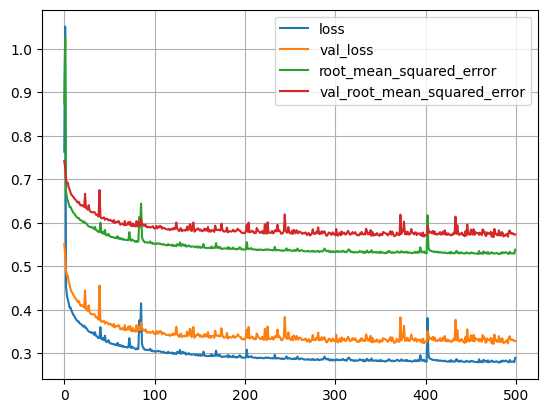

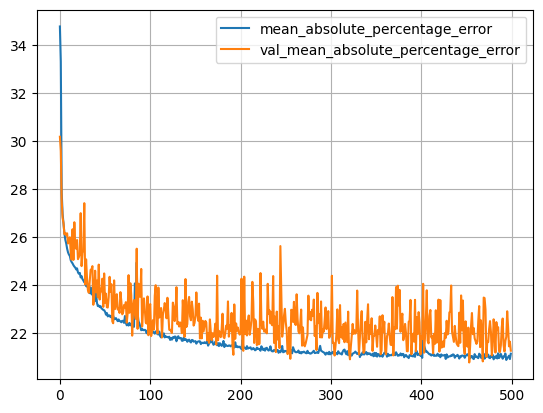

In [ ]:
# Graficar el historial de entrenamiento:
# Hacer una prueba durante el entrenamiento,
# Siempre el error va a disminuir, a medida que las èpocas aumenten.
dfHistory = pd.DataFrame(history.history)
dfHistory[['loss', 'val_loss', 'root_mean_squared_error',
           'val_root_mean_squared_error']].plot(grid=True)
dfHistory[['mean_absolute_percentage_error',
           'val_mean_absolute_percentage_error']].plot(grid=True)

In [ ]:
# Evaluar el modelo en el conjunto de entrenamiento
loss, RMSE, MAPE = model.evaluate(X_train, y_train)
print("Evaluar el modelo en el conjunto de entrenamiento")
print("loss train:", loss)
print("root_mean_squared_error train:", RMSE)
print("mean_absolute_percentage_error train:", MAPE)


363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2766 - mean_absolute_percentage_error: 20.0092 - root_mean_squared_error: 0.5257
Evaluar el modelo en el conjunto de entrenamiento
loss train: 0.2765481472015381
root_mean_squared_error train: 0.5258784890174866
mean_absolute_percentage_error train: 20.210798263549805


In [ ]:
# Evaluar el modelo en el conjunto de validacion
loss, RMSE, MAPE = model.evaluate(X_valid, y_valid)
print("Evaluar el modelo en el conjunto de validacion")
print("loss valid:", loss)
print("root_mean_squared_error valid:", RMSE)
print("mean_absolute_percentage_error valid:", MAPE)



121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3142 - mean_absolute_percentage_error: 20.6927 - root_mean_squared_error: 0.5597
Evaluar el modelo en el conjunto de validacion
loss valid: 0.32818880677223206
root_mean_squared_error valid: 0.5728776454925537
mean_absolute_percentage_error valid: 21.251379013061523


In [ ]:
# Evaluar el modelo en el conjunto de prueba
# Loss > Pérdida, RMSE >
loss, RMSE, MAPE = model.evaluate(X_test, y_test) #Variables que se quieren medir, en X e Y, de Test,
print("Evaluar el modelo en el conjunto de prueba")
print("loss test:", loss)
print("root_mean_squared_error test:", RMSE)
print("mean_absolute_percentage_error test:", MAPE)

162/162 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3357 - mean_absolute_percentage_error: 21.0454 - root_mean_squared_error: 0.5774
Evaluar el modelo en el conjunto de prueba
loss test: 0.3176648020744324
root_mean_squared_error test: 0.5636175870895386
mean_absolute_percentage_error test: 20.912843704223633
